### QQP with S4

In [10]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from qqp_task import QQPTask
from src.train_utils.trainer import Trainer

### Configuration

In [11]:
from src.utils.block_factory import make_s4_block_cfg_ctor

In [12]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "qqp" / "data")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 256,
    "data_loader_kwargs": {
        "num_workers": 0,
        "max_len": 64,
        "max_vocab": 50_000,
        "min_freq": 2,
        "lowercase": True,
        "val_ratio": 0.1,
        "test_ratio": 0.1,
        "pin_memory": False,
        "persistent_workers": False,
        "seed": 42,
    },

    "epochs": 50,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/qqp_s4_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 1,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",

    # QQP specific
    "max_len": 64,
}

args["block_cfg_ctor"] = make_s4_block_cfg_ctor(
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print("Using CUDA")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("Using CPU")

Using MPS


### Training

In [13]:
from src.utils.visualization import plot_classification_history as plot_history

In [6]:
task = QQPTask()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
Using embedding layer with vocab_size=49367


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


saved best model to ./runs/qqp_s4_task/best.pt
new best acc 0.4641
Epoch 000/50 | train 0.7126/0.3800 | val 0.6955/0.4641 | t 225.2s/10.3s | lr 1.00e-06


saved best model to ./runs/qqp_s4_task/best.pt
new best acc 0.6450
Epoch 001/50 | train 0.6353/0.6315 | val 0.6183/0.6450 | t 232.5s/10.0s | lr 2.01e-04


saved best model to ./runs/qqp_s4_task/best.pt
new best acc 0.7211
Epoch 002/50 | train 0.5832/0.6814 | val 0.5475/0.7211 | t 232.0s/9.9s | lr 4.01e-04


...

Epoch 024/50 | train 0.3016/0.8672 | val 0.4974/0.7989 | t 210.6s/9.2s | lr 6.21e-04


Epoch 025/50 | train 0.2972/0.8701 | val 0.5535/0.7865 | t 208.8s/9.2s | lr 5.87e-04


Epoch 026/50 | train 0.2933/0.8717 | val 0.5134/0.7914 | t 208.8s/9.2s | lr 5.52e-04


Epoch 027/50 | train 0.2894/0.8737 | val 0.5054/0.7977 | t 215.4s/9.9s | lr 5.17e-04


Early stopping (patience=5, best=0.8033).
Training history saved to ./runs/qqp_s4_task/history.json
Done. Best acc=0.8033 @ ./runs/qqp_s4_task/best.pt


### Visualization

Load the best checkpoint and visualize the training history.

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 22
Val metrics: {'loss': 0.4554717355264166, 'time_s': 9.194119750000027, 'acc': 0.8032644985779647}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


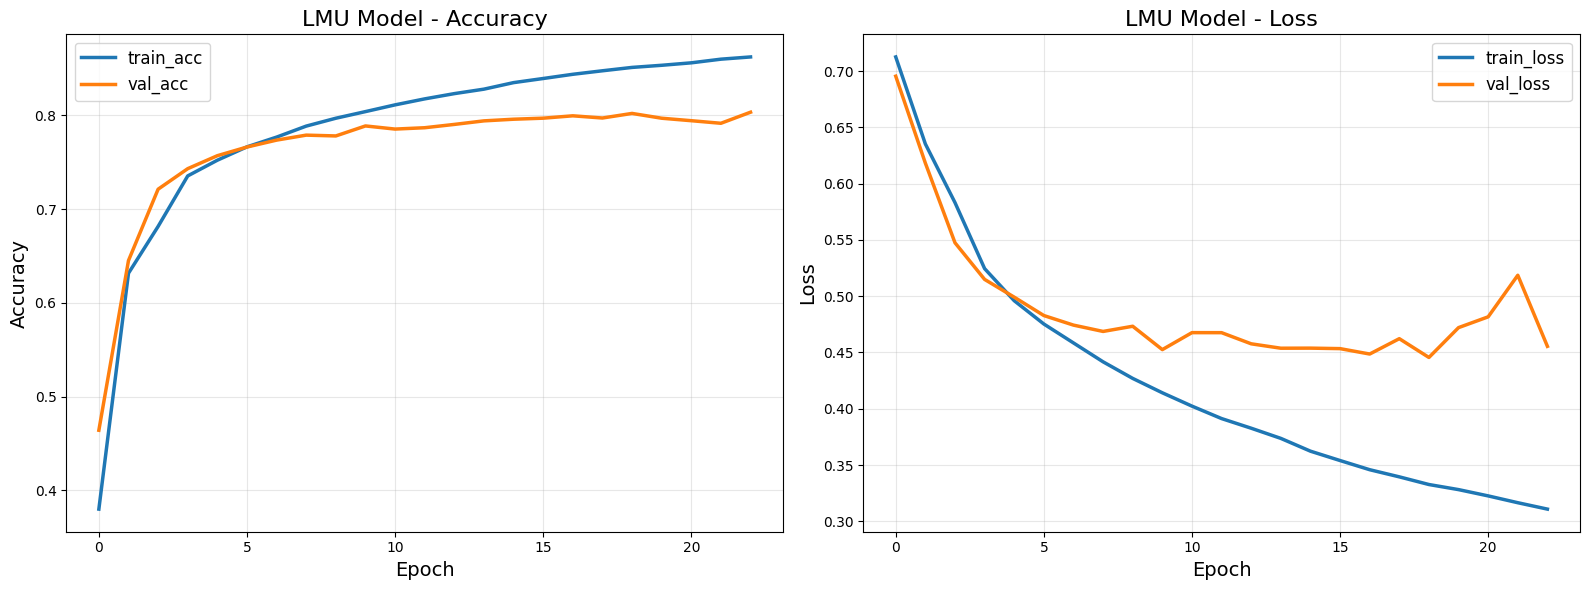

In [7]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=QQPTask(),
)

history = trainer.history

plot_history(history, model_name="LMU")

### Evaluation

After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 22
Val metrics: {'loss': 0.4554717355264166, 'time_s': 9.194119750000027, 'acc': 0.8032644985779647}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}

 Test results saved to: runs/qqp_s4_task/test_results.json

   Test Accuracy: 0.8071 (80.71%)
   Test Loss: 0.4496

TEST SET RESULTS
Overall accuracy: 0.8071
Num classes: 2

1. ROC Curve...


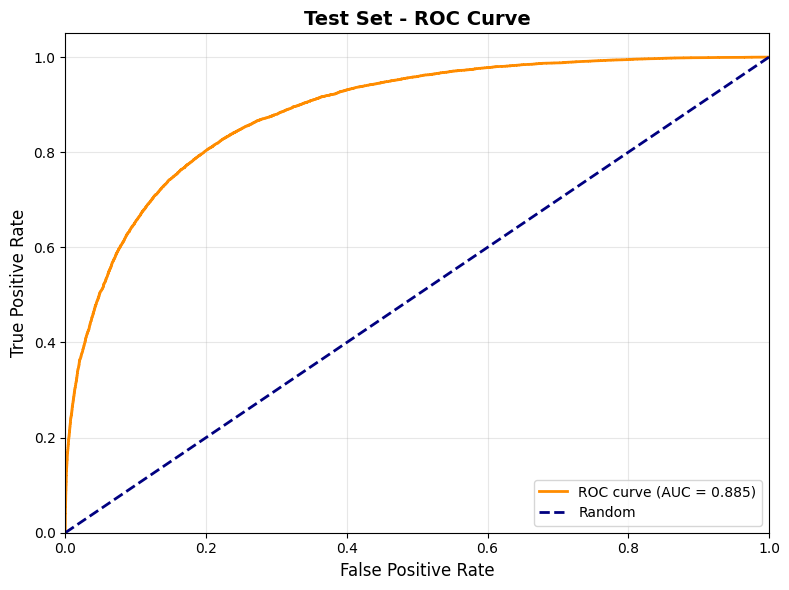

2. Precision-Recall Curve...


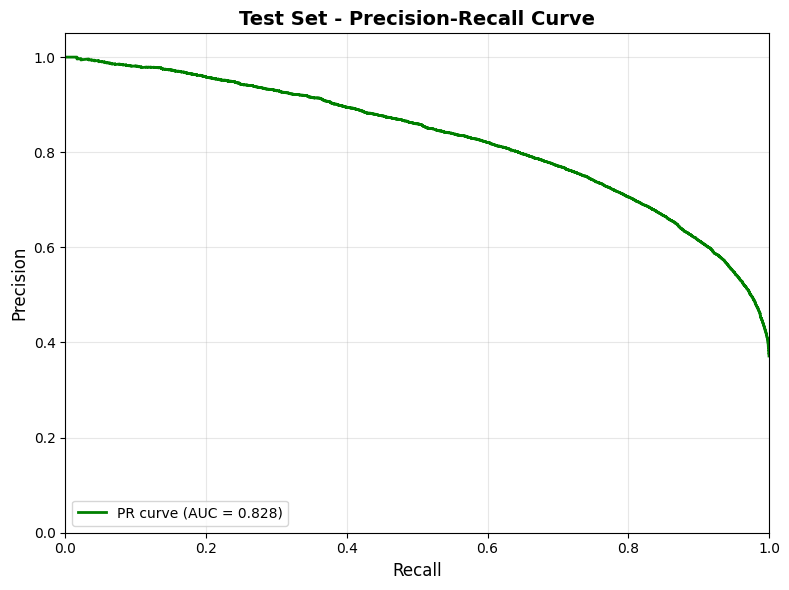

3. Confusion Matrix...


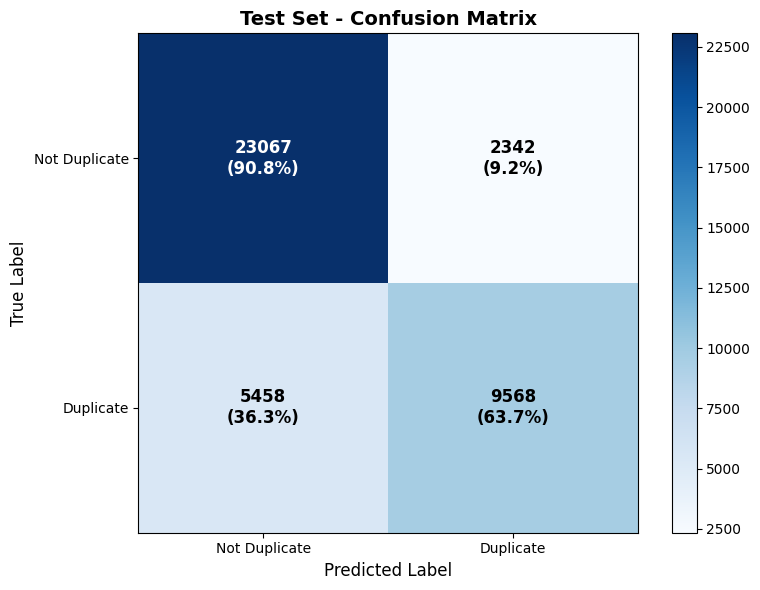

4. Threshold Analysis...


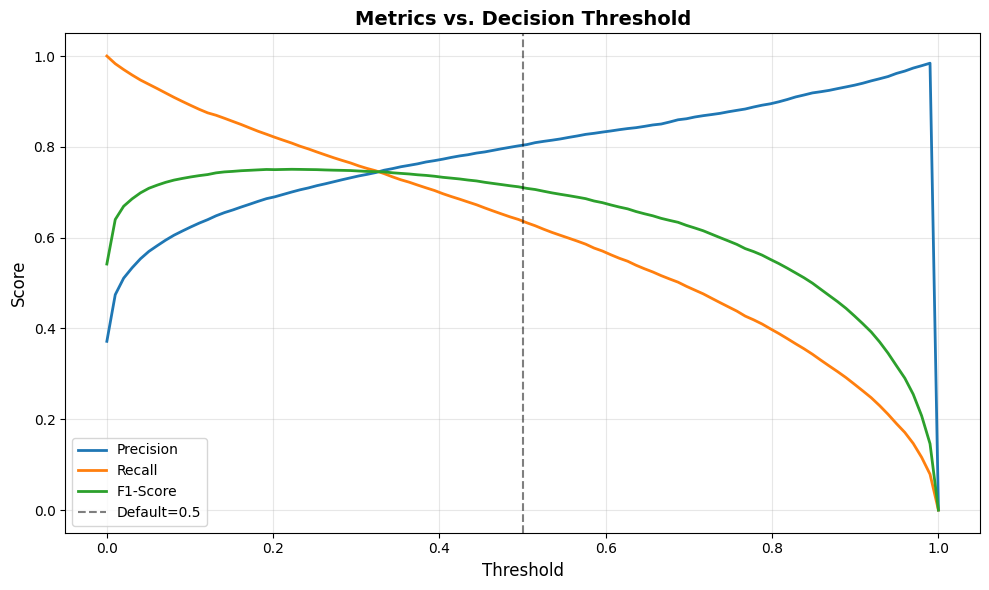

5. Metrics Summary...


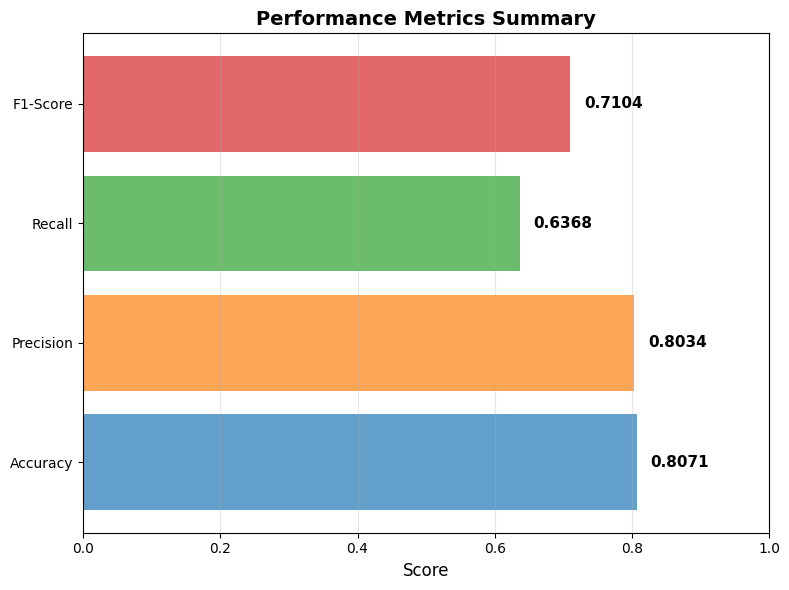

6. Class Distribution...


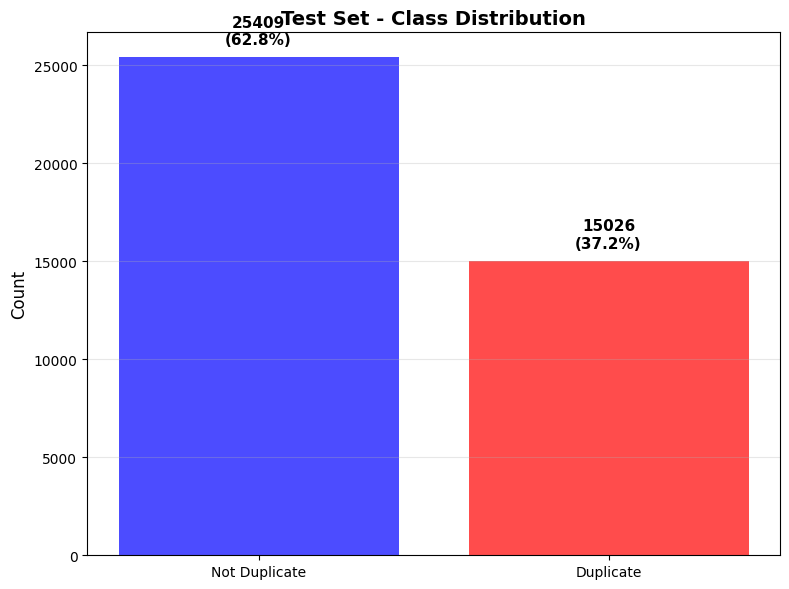


All visualizations generated!


In [8]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=QQPTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=2,
    use_test_set=True,
)

### Training with Different Dataset Fractions

This cell demonstrates training with different fractions of the training data
to see how model performance scales with dataset size.


Training with fraction: 0.1
QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 10.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 32347
   Reduced val size: 40435
   Test size: 40435 (unchanged)
Using embedding layer with vocab_size=49367


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


saved best model to ./runs/qqp_s4_task_frac_10/best.pt
new best acc 0.6324
Epoch 000/50 | train 0.6670/0.6307 | val 0.6658/0.6324 | t 22.4s/9.2s | lr 1.00e-06


Epoch 001/50 | train 0.6633/0.6305 | val 0.6598/0.6324 | t 20.5s/9.2s | lr 2.01e-04


Epoch 002/50 | train 0.6518/0.6311 | val 0.6410/0.6324 | t 20.4s/9.1s | lr 4.01e-04


...

Epoch 014/50 | train 0.4584/0.7780 | val 0.5372/0.7376 | t 20.7s/9.3s | lr 9.05e-04


Epoch 015/50 | train 0.4463/0.7855 | val 0.5600/0.7165 | t 20.8s/9.3s | lr 8.83e-04


Epoch 016/50 | train 0.4378/0.7905 | val 0.5579/0.7222 | t 20.6s/9.3s | lr 8.60e-04


Epoch 017/50 | train 0.4265/0.7970 | val 0.5705/0.7145 | t 20.6s/9.3s | lr 8.35e-04


Early stopping (patience=5, best=0.7372).
Training history saved to ./runs/qqp_s4_task_frac_10/history.json

Training complete for fraction 0.1! Best validation acc: 0.7372
Best model saved to: ./runs/qqp_s4_task_frac_10/best.pt


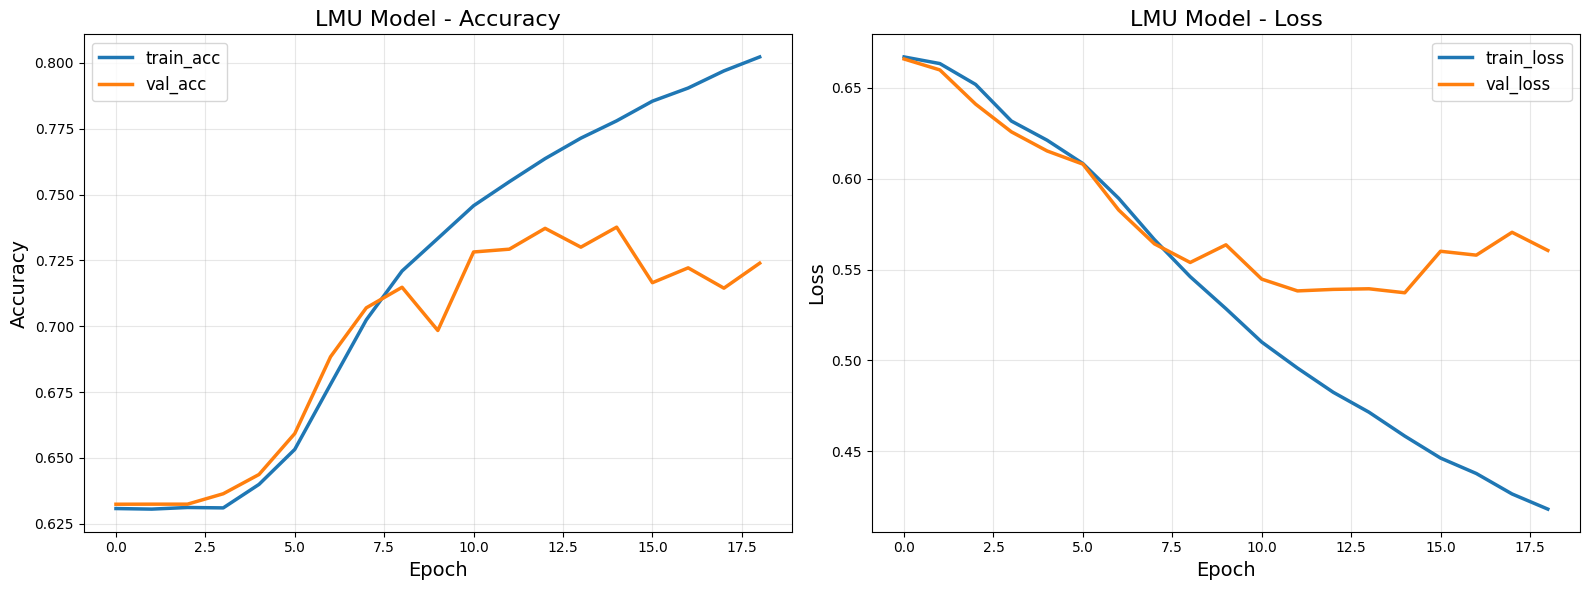

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 10.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 32347
   Reduced val size: 40435
   Test size: 40435 (unchanged)
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 12
Val metrics: {'loss': 0.5390613963242232, 'time_s': 9.21291116700013, 'acc': 0.7371831334240139}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}

 Test results saved to: runs/qqp_s4_task_frac_10/test_results.json

   Test Accuracy: 0.7355 (73.55%)
   Test Loss: 0.5381

TEST SET RESULTS
Overall accuracy: 0.7355
Num classes: 2

1. ROC Curve...


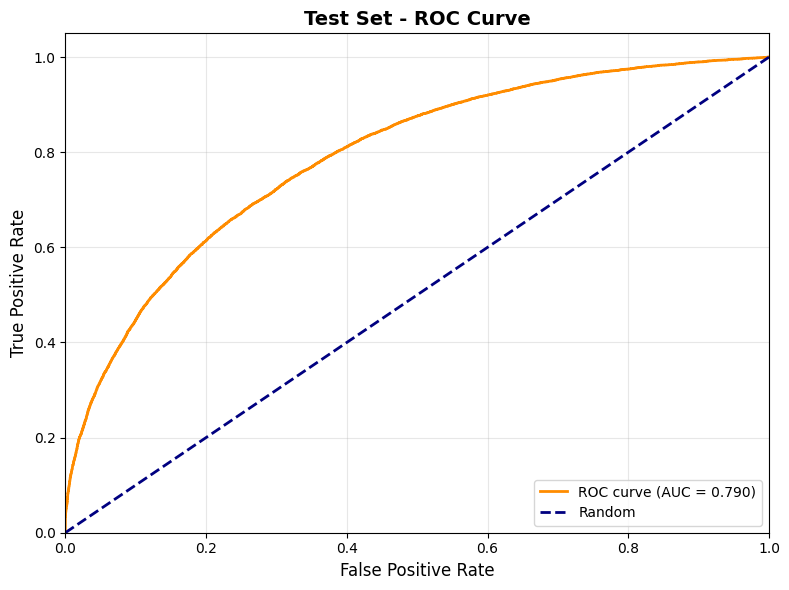

2. Precision-Recall Curve...


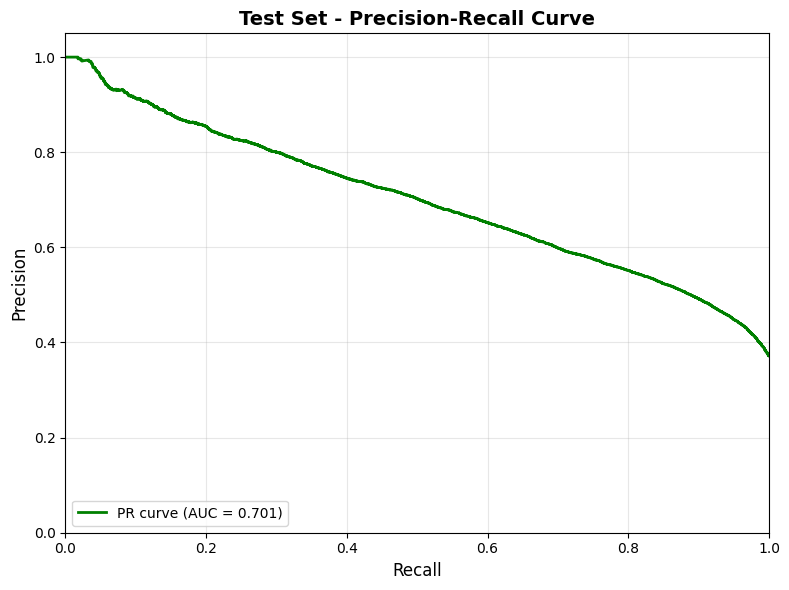

3. Confusion Matrix...


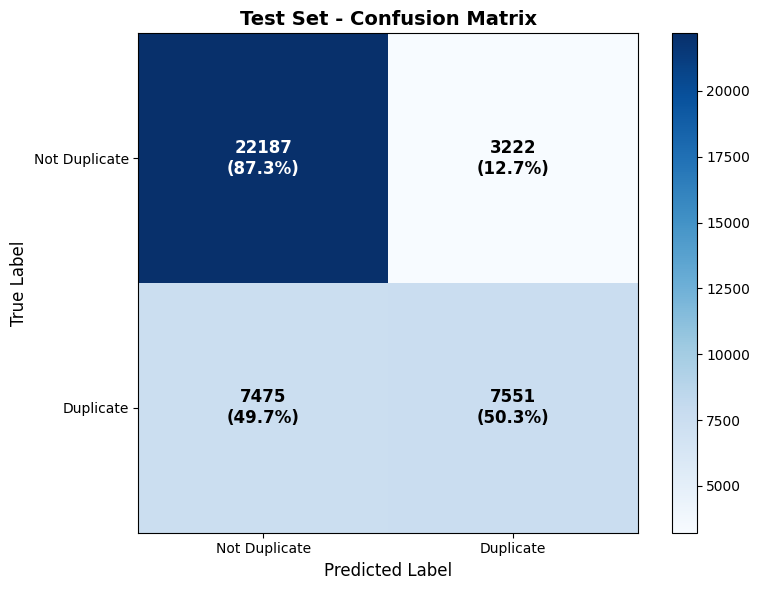

4. Threshold Analysis...


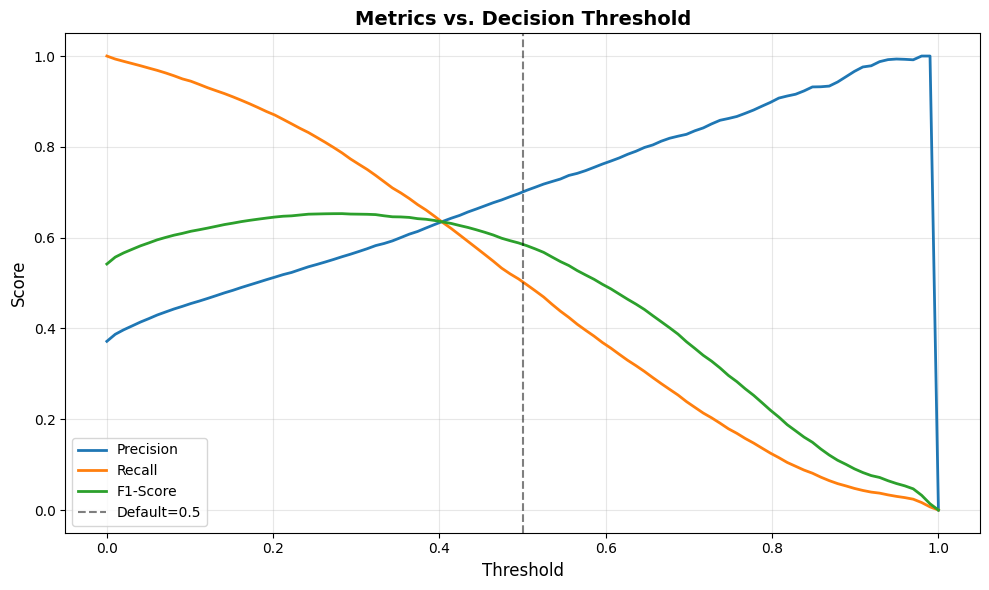

5. Metrics Summary...


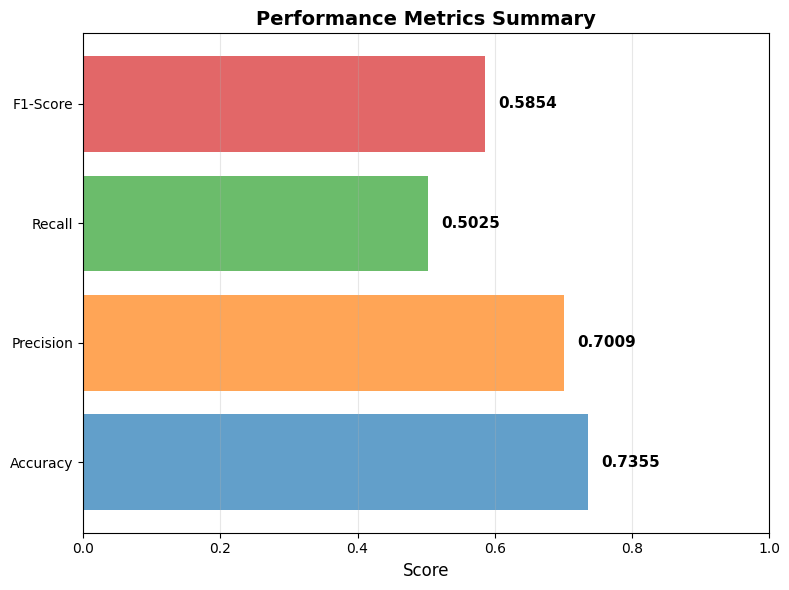

6. Class Distribution...


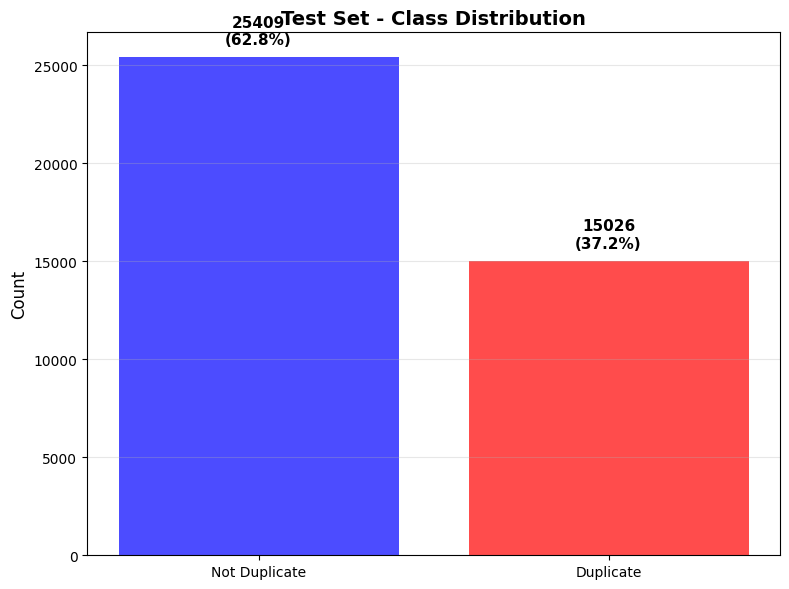


All visualizations generated!

Training with fraction: 0.25
QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 25.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 80870
   Reduced val size: 40435
   Test size: 40435 (unchanged)


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


Using embedding layer with vocab_size=49367


saved best model to ./runs/qqp_s4_task_frac_25/best.pt
new best acc 0.3677
Epoch 000/50 | train 0.7448/0.3694 | val 0.7398/0.3677 | t 51.3s/9.2s | lr 1.00e-06


saved best model to ./runs/qqp_s4_task_frac_25/best.pt
new best acc 0.6324
Epoch 001/50 | train 0.6607/0.6242 | val 0.6488/0.6324 | t 51.9s/9.2s | lr 2.01e-04


...

Epoch 022/50 | train 0.3712/0.8286 | val 0.5371/0.7571 | t 55.0s/9.7s | lr 6.87e-04


Epoch 023/50 | train 0.3671/0.8299 | val 0.5346/0.7565 | t 55.1s/9.8s | lr 6.55e-04


Epoch 024/50 | train 0.3615/0.8343 | val 0.5404/0.7546 | t 55.3s/9.8s | lr 6.21e-04


Epoch 025/50 | train 0.3562/0.8365 | val 0.5424/0.7506 | t 55.3s/9.9s | lr 5.87e-04


Early stopping (patience=5, best=0.7579).
Training history saved to ./runs/qqp_s4_task_frac_25/history.json

Training complete for fraction 0.25! Best validation acc: 0.7579
Best model saved to: ./runs/qqp_s4_task_frac_25/best.pt


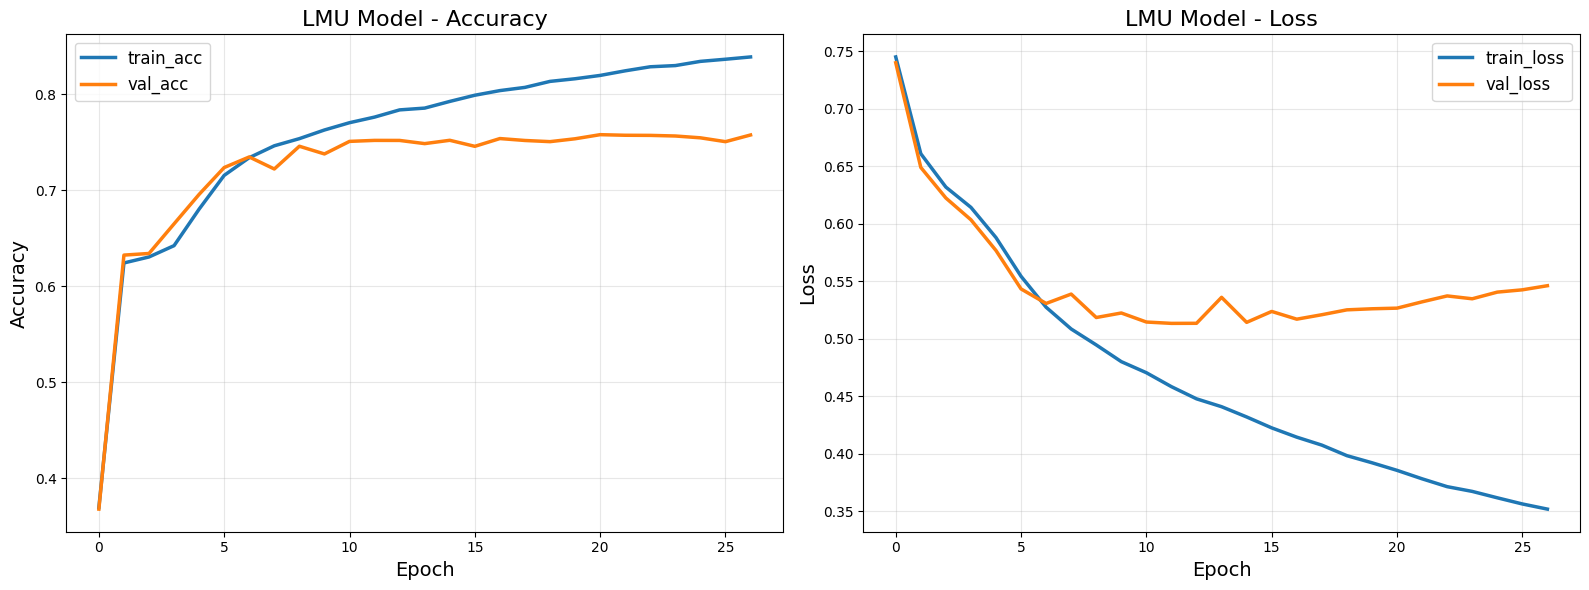

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 25.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 80870
   Reduced val size: 40435
   Test size: 40435 (unchanged)
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 20
Val metrics: {'loss': 0.5264335674490432, 'time_s': 9.75290912499986, 'acc': 0.7578830221342896}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}

 Test results saved to: runs/qqp_s4_task_frac_25/test_results.json

   Test Accuracy: 0.7615 (76.15%)
   Test Loss: 0.5186

TEST SET RESULTS
Overall accuracy: 0.7615
Num classes: 2

1. ROC Curve...


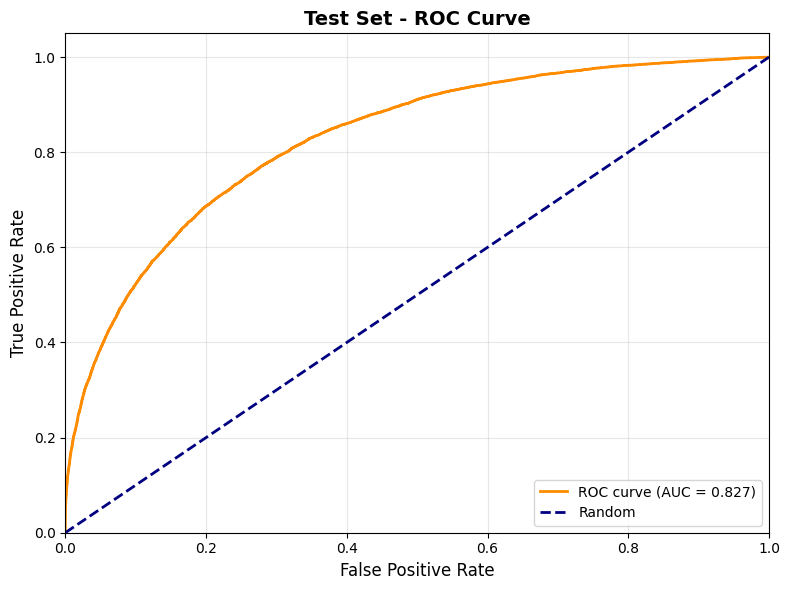

2. Precision-Recall Curve...


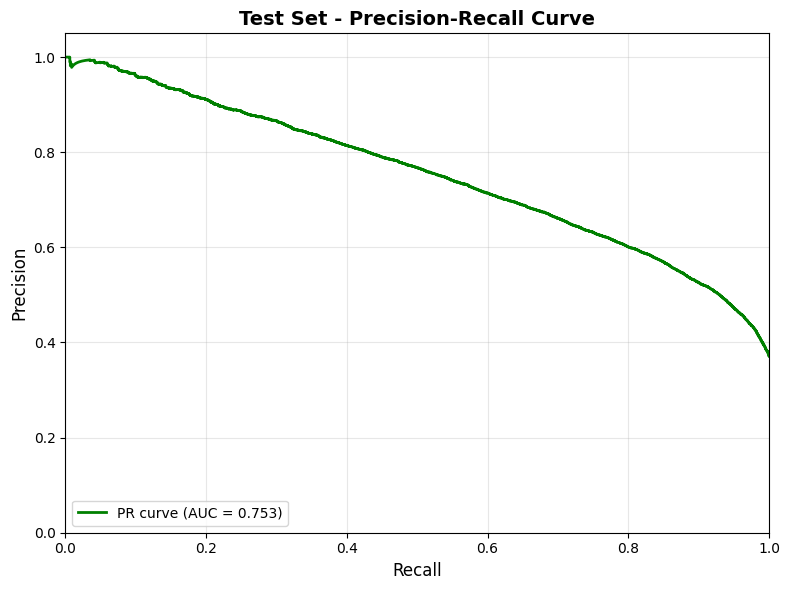

3. Confusion Matrix...


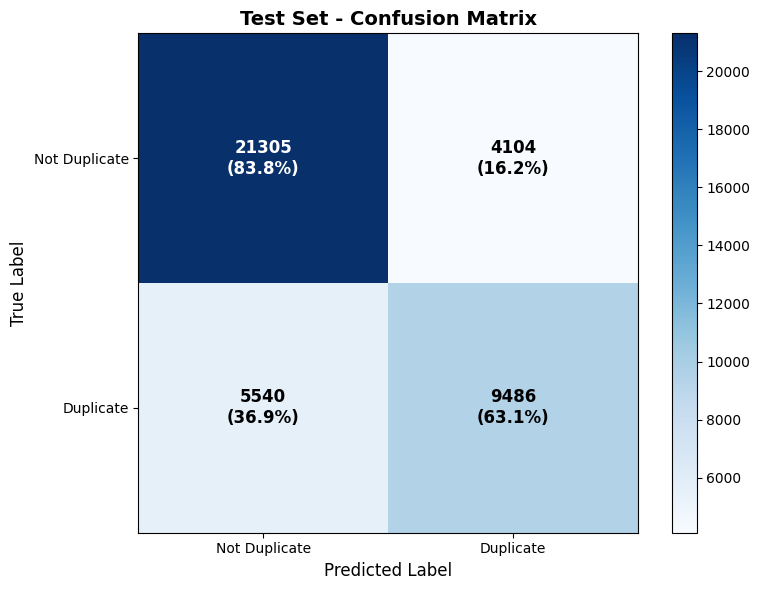

4. Threshold Analysis...


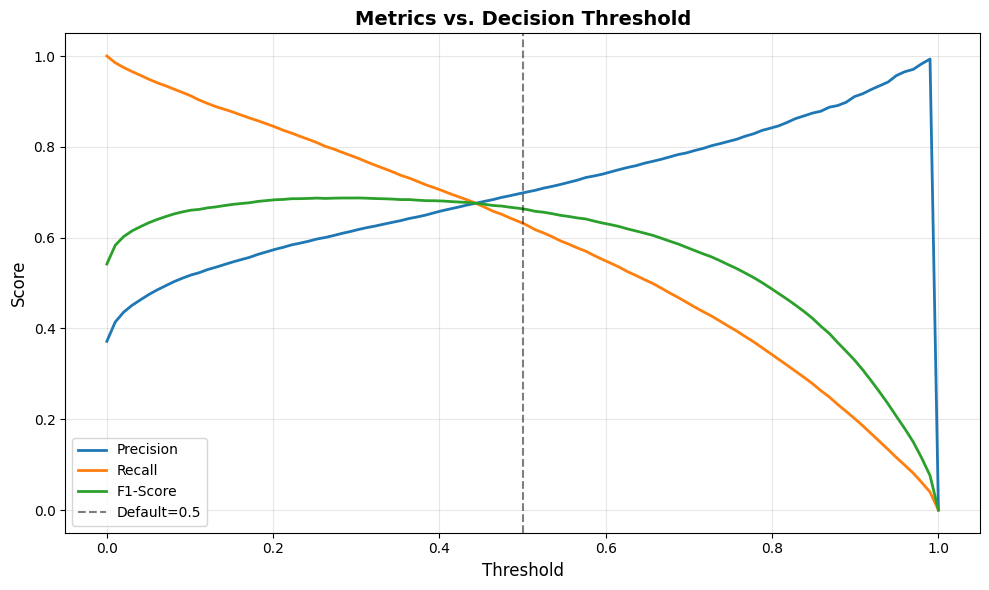

5. Metrics Summary...


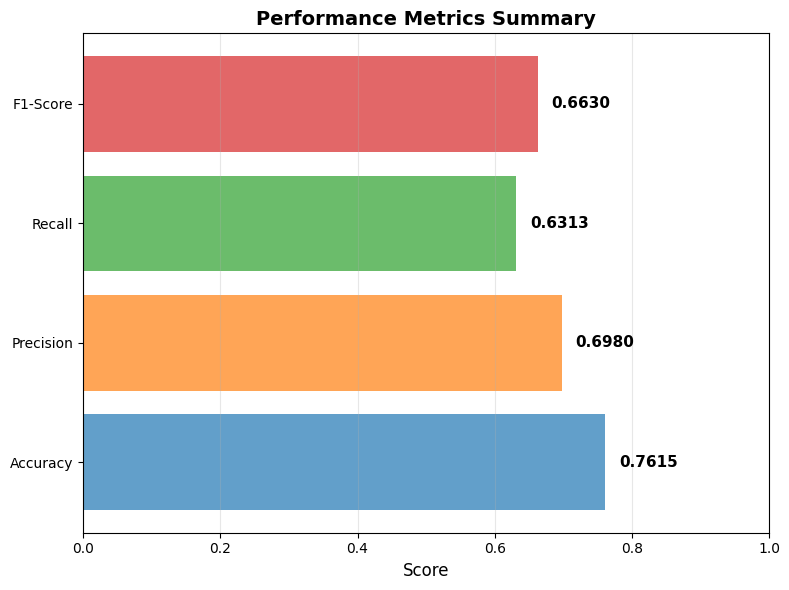

6. Class Distribution...


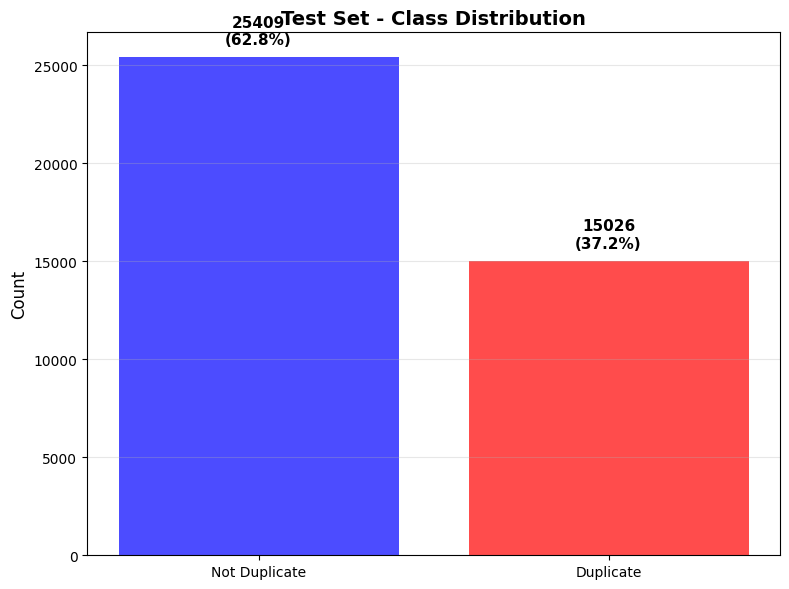


All visualizations generated!

Training with fraction: 0.5
QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 50.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 161740
   Reduced val size: 40435
   Test size: 40435 (unchanged)


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


Using embedding layer with vocab_size=49367


saved best model to ./runs/qqp_s4_task_frac_50/best.pt
new best acc 0.6318
Epoch 000/50 | train 0.6672/0.6304 | val 0.6658/0.6318 | t 109.2s/9.9s | lr 1.00e-06


Epoch 001/50 | train 0.6474/0.6306 | val 0.6281/0.6290 | t 111.8s/9.9s | lr 2.01e-04


...

Epoch 036/50 | train 0.2854/0.8774 | val 0.5229/0.7877 | t 116.0s/9.8s | lr 2.20e-04


Epoch 037/50 | train 0.2830/0.8778 | val 0.5443/0.7857 | t 111.4s/9.9s | lr 1.92e-04


Epoch 038/50 | train 0.2820/0.8791 | val 0.5267/0.7868 | t 113.2s/9.9s | lr 1.65e-04


Epoch 039/50 | train 0.2797/0.8797 | val 0.5376/0.7873 | t 112.2s/9.8s | lr 1.40e-04


Early stopping (patience=5, best=0.7890).
Training history saved to ./runs/qqp_s4_task_frac_50/history.json

Training complete for fraction 0.5! Best validation acc: 0.7890
Best model saved to: ./runs/qqp_s4_task_frac_50/best.pt


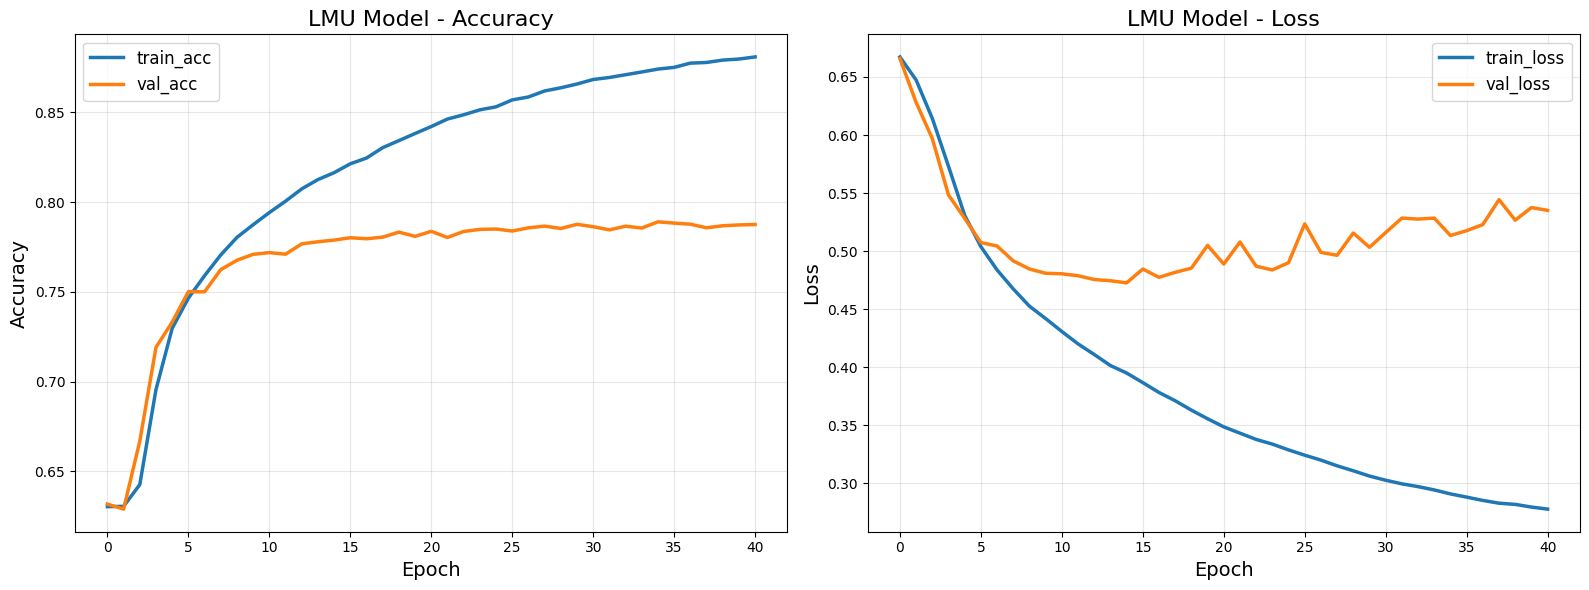

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
   Applying data fraction: 50.0%
   Original train size: 323481
   Original val size: 40435
   Reduced train size: 161740
   Reduced val size: 40435
   Test size: 40435 (unchanged)
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 34
Val metrics: {'loss': 0.5134965319671515, 'time_s': 9.847721750000346, 'acc': 0.789019413874119}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}

 Test results saved to: runs/qqp_s4_task_frac_50/test_results.json

   Test Accuracy: 0.7904 (79.04%)
   Test Loss: 0.5090

TEST SET RESULTS
Overall accuracy: 0.7904
Num classes: 2

1. ROC Curve...


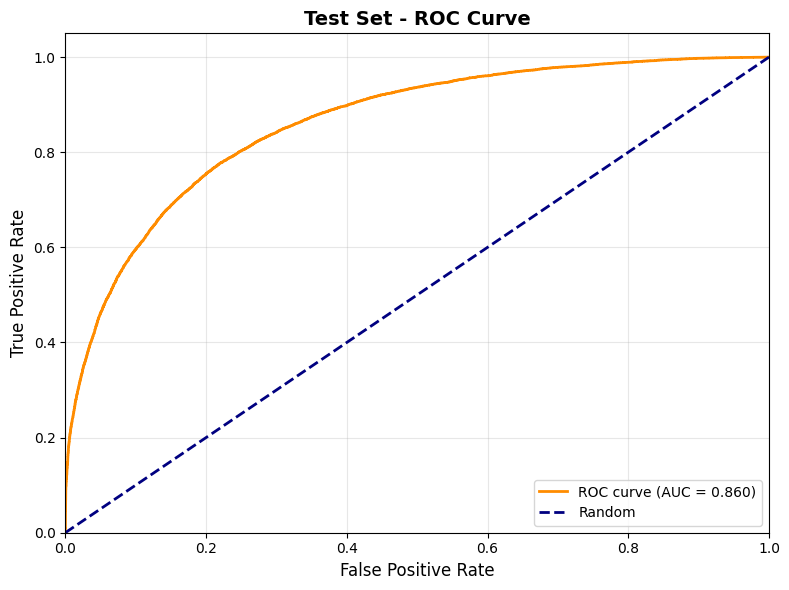

2. Precision-Recall Curve...


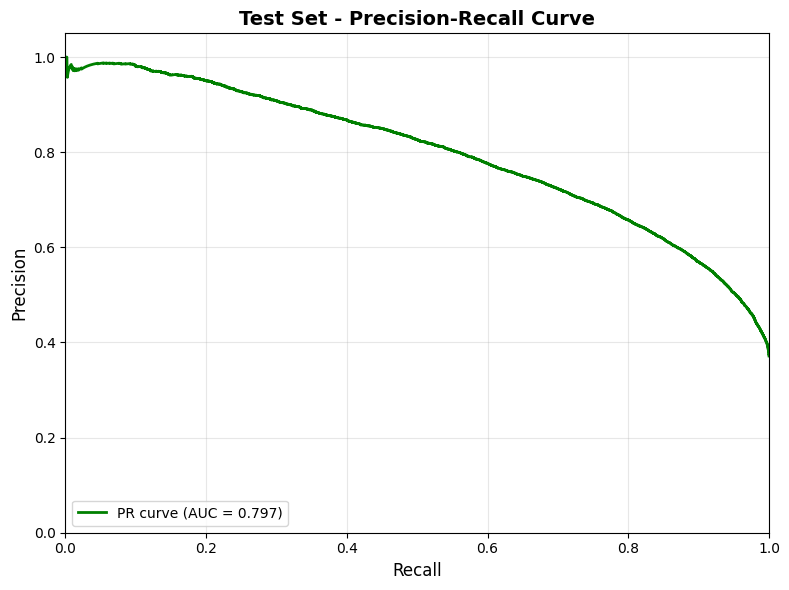

3. Confusion Matrix...


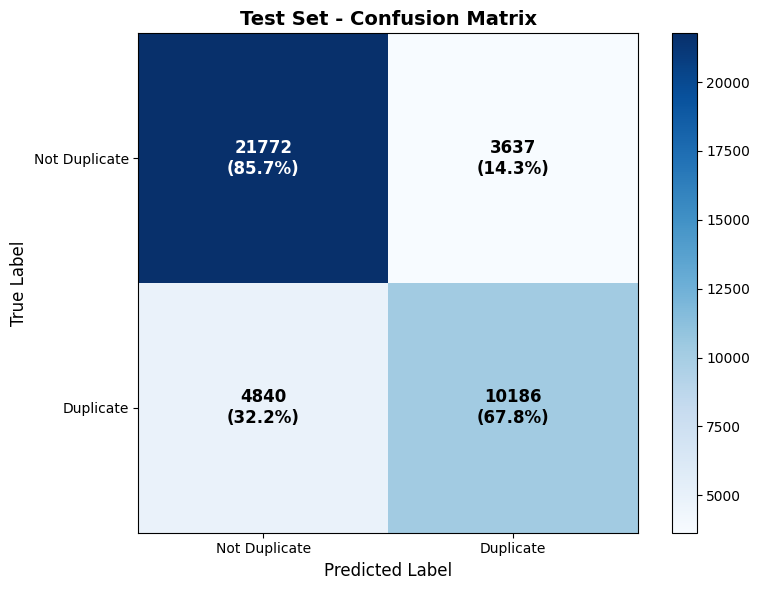

4. Threshold Analysis...


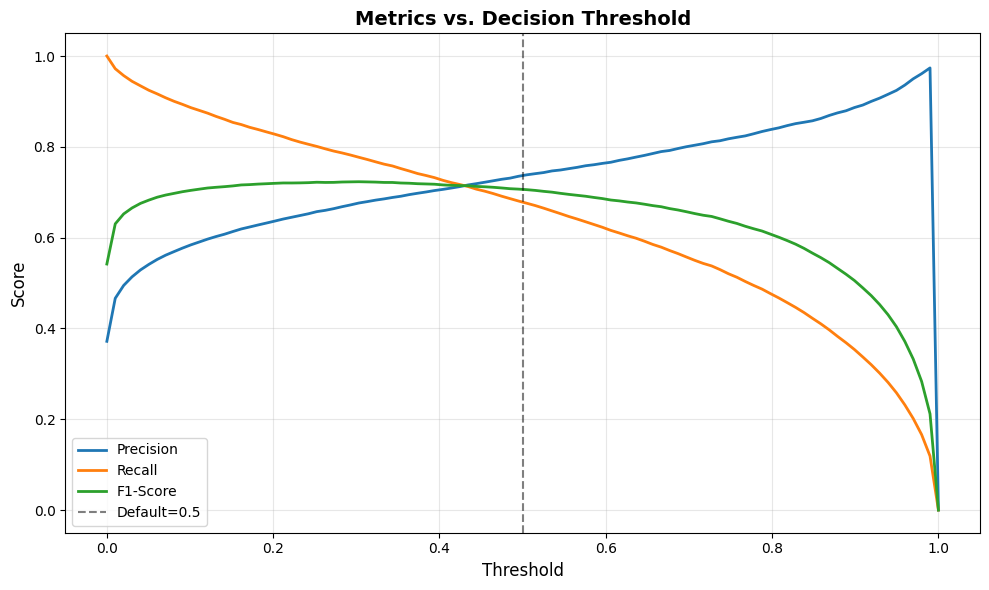

5. Metrics Summary...


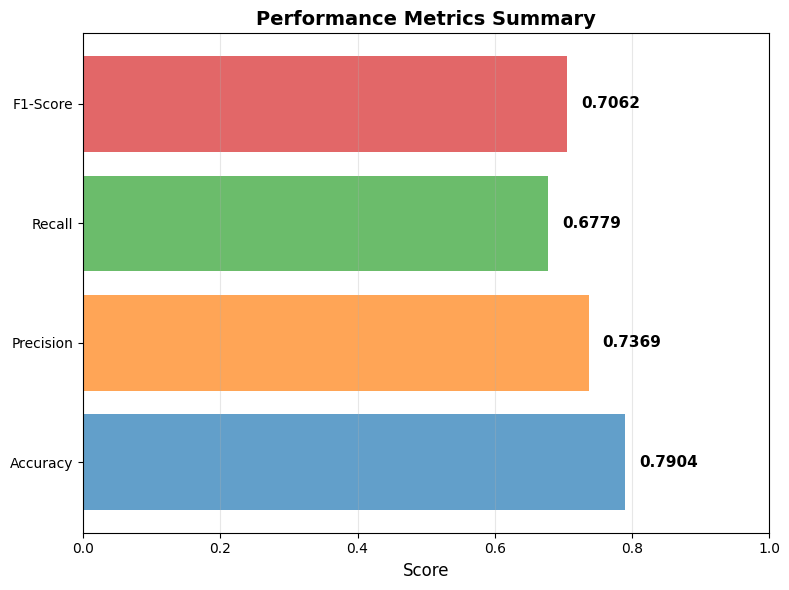

6. Class Distribution...


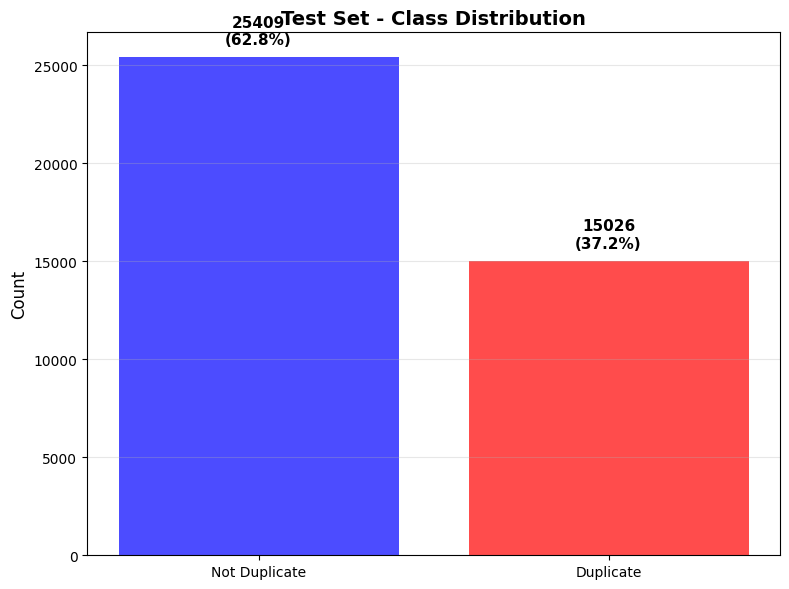


All visualizations generated!


In [14]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/qqp_s4_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=QQPTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history
    plot_history(history, model_name="LMU")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=QQPTask(),
        best_model_path=best_path,
        num_classes=2,
        use_test_set=True,
    )